In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve 


Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('train.csv')
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived', 'Parch', 'SibSp']]
df.dropna(inplace=True)

#convert sex to numbers 0-1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(df.shape)
print(df.isnull().sum())
df.head(10)

(714, 7)
Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
Parch       0
SibSp       0
dtype: int64


,Pclass,Sex,Age,Fare,Survived,Parch,SibSp
0,3,0,22.0,7.2500,0,0,1
1,1,1,38.0,71.2833,1,0,1
2,3,1,26.0,7.9250,1,0,0
3,1,1,35.0,53.1000,1,0,1
4,3,0,35.0,8.0500,0,0,0
6,1,0,54.0,51.8625,0,0,0
7,3,0,2.0,21.0750,0,1,3
8,3,1,27.0,11.1333,1,2,0
9,2,1,14.0,30.0708,1,0,1
10,3,1,4.0,16.7000,1,1,1


In [3]:
#split data 

x =df.drop(columns='Survived')
y = df['Survived']

#train split test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [4]:
#train the model 
model = LogisticRegression()
model.fit(x_train, y_train)

print("Model Trained Successfully")


Model Trained Successfully


In [5]:
#prediction 
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7483


In [6]:
#ROC and AUC 

y_proba = model.predict_proba(x_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8164


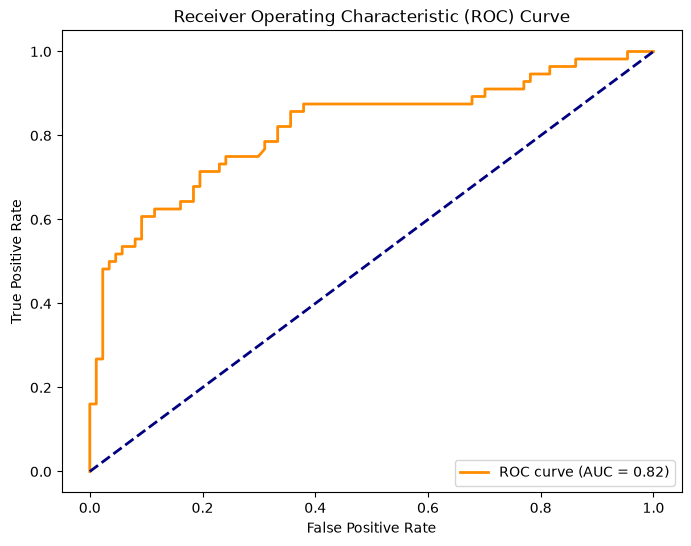

In [7]:
#plot 

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()